# Set up

## Load libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns; sns.set()
from matplotlib import pyplot as plt

# Compare
## Get bucket
import os
## Get URIs
import awswrangler as wr
## Filter out accounts that are too recent
import datetime
## Plot
import shutil
from skylar_toolbox import exploratory_data_analysis as steda
## Evaluate
import json
from sklearn import metrics as snmes

## Declare constants

In [2]:
# Compare
## Read in predictions
account_col_sr = 'bigaccountid__app'
bk_col_sr = 'intopenbktype__app'
target_col_sr = 'DQ15_2'
pred_proba_col_sr = f'yhat_{target_col_sr}'
columns_lt = [
    'uniqueid__app', account_col_sr, 'bigdebtorid__app', 'applicationdate__app', 'dtmfunded__app', 
    bk_col_sr, pred_proba_col_sr, 'yhat_ad', 'yhat_pricing_lgd']
## Cast dtypes
dtypes_dt = {
    'uniqueid__app': int,
    account_col_sr: int,
    'bigdebtorid__app': int,
    bk_col_sr: int}
date_col_sr = 'dtmfunded__app'
dates_lt = [
    'applicationdate__app',
    date_col_sr]
## Read in previous actuals used in training
account_col_sr2 = 'bigAccountId'
columns_lt2 = ['UniqueID', account_col_sr2, 'bigDebtorId', target_col_sr]

## Define functions and classes

In [3]:
class Evaluator:
    def __init__(self, target_col_sr, pred_col_sr, pred_proba_col_sr, facet_col_sr=None):
        self.target_col_sr = target_col_sr
        self.pred_col_sr = pred_col_sr
        self.pred_proba_col_sr = pred_proba_col_sr
        self.facet_col_sr = facet_col_sr
        
    def fit(self, merged_df):
        if self.facet_col_sr:
            # Cast to string
            merged_df[self.facet_col_sr] = merged_df[self.facet_col_sr].astype(dtype=str)
            
            # Get facet values
            self.facet_vals_ay = merged_df[self.facet_col_sr].drop_duplicates().sort_values().values
            
            # Get classification report
            self.classification_report_dt = {
                str(val): self._get_classification_report(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'))
                for val in self.facet_vals_ay}
            
            # Get other metrics
            self.other_metrics_dt = {
                str(val): self._get_other_metrics(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'))
                for val in self.facet_vals_ay}

            # Get ROC curve
            for index_it, val in enumerate(iterable=self.facet_vals_ay):
                if not index_it:
                    self.rcd = self._get_roc_curve(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'))
                else:
                    self.rcd = self._get_roc_curve(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'), ax=self.rcd.ax_)
            self._fix_legend()
            plt.close()

            # Get PR curve
            for index_it, val in enumerate(iterable=self.facet_vals_ay):
                if not index_it:
                    self.prd = self._get_pr_curve(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'))
                else:
                    self.prd = self._get_pr_curve(df=merged_df.query(expr=f'{self.facet_col_sr} == "{val}"'), ax=self.prd.ax_)
            self.prd.ax_.get_legend().set_loc(loc='upper right')
            plt.close()
        else:
            # Get classification report
            self.classification_report_dt = self._get_classification_report(df=merged_df)

            # Get other metrics
            self.other_metrics_dt = self._get_other_metrics(df=merged_df)
            
            # Get ROC curve
            self.rcd = self._get_roc_curve(df=merged_df)
            plt.close()

            # Get PR curve
            self.prd = self._get_pr_curve(df=merged_df)
            self.prd.ax_.get_legend().set_loc(loc='upper right')
            plt.close()
        
        # Get predictions plot
        self.predictions_fig = self._get_predictions_plot(df=merged_df)
        plt.close()
                    
    def _get_classification_report(self, df):
        report_sr = snmes.classification_report(
            y_true=df[self.target_col_sr], 
            y_pred=df[self.pred_col_sr], 
            output_dict=False)
        
        if self.facet_col_sr:
            facet_val_sr = df[self.facet_col_sr].values[0]
            print('-' * int(8e1), facet_val_sr, report_sr, sep='\n')
        else:
            print('-' * int(8e1), report_sr, sep='\n')
        
        classification_report_dt = snmes.classification_report(
            y_true=df[self.target_col_sr], 
            y_pred=df[self.pred_col_sr], 
            output_dict=True)
        return classification_report_dt
    
    def _get_other_metrics(self, df):
        other_metrics_dt = {
            fn.__name__: fn(df[self.target_col_sr], df[pred_sr])
            for fn, pred_sr in [
                (snmes.accuracy_score, self.pred_col_sr),
                (snmes.balanced_accuracy_score, self.pred_col_sr),
                (snmes.log_loss, self.pred_proba_col_sr),
                (snmes.roc_auc_score, self.pred_proba_col_sr)]}
        return other_metrics_dt
                
    def _get_roc_curve(self, df, ax=None):
        rcd = snmes.RocCurveDisplay.from_predictions(
            y_true=df[self.target_col_sr], 
            y_pred=df[self.pred_proba_col_sr], 
            ax=ax,
            plot_chance_level=True)
        return rcd
    
    def _fix_legend(self):
        legend_df = pd.DataFrame(
            data=self.rcd.ax_.get_legend_handles_labels(), 
            index=['handles', 'labels']).T
        legend_ix = legend_df.index[legend_df.index % 2 == 0].union(other=[1])
        legend_df = (
            legend_df
            # Drop multiple chance labels
            .loc[legend_ix, :]
            .set_axis(labels=[er.facet_vals_ay[0], 'chance'] + er.facet_vals_ay[1:].tolist())
            # Append facet value
            .assign(labels = lambda x: x['labels'].where(cond=x.index == 'chance', other=x['labels'] + ': ' + x.index))
            .sort_values(by='labels'))
        self.rcd.ax_.legend(
            handles=legend_df['handles'].tolist(),
            labels=legend_df['labels'].tolist())
    
    def _get_pr_curve(self, df, ax=None):
        prd = snmes.PrecisionRecallDisplay.from_predictions(
            y_true=df[self.target_col_sr], 
            y_pred=df[self.pred_proba_col_sr], 
            ax=ax,
            plot_chance_level=True)
        return prd
    
    def _get_predictions_plot(self, df):
        displot_dt = dict(data=df, x=self.pred_proba_col_sr, height=3, aspect=2)
        
        if self.facet_col_sr:
            fg = sns.displot(
                row=self.facet_col_sr, 
                row_order=df[self.facet_col_sr].drop_duplicates().sort_values().tolist(), 
                **displot_dt)
            for ax in fg.axes.ravel():
                facet_val_sr = ax.title._text.split(' = ')[-1]
                data_df = pd.concat(objs=[
                    df.query(expr=f'{self.facet_col_sr} == "{facet_val_sr}"')[column_sr].describe()
                    for column_sr in [pred_proba_col_sr, target_col_sr]
                ], axis=1)
                ax.axvline(x=data_df.loc['mean', self.target_col_sr])
                pd.plotting.table(ax=ax, data=data_df.round(decimals=3), bbox=[1.2, 0, 4e-1, 1])
        else:
            fg = sns.displot(**displot_dt)
            for ax in fg.axes.ravel():
                data_df = pd.concat(objs=[
                    df[column_sr].describe()
                    for column_sr in [pred_proba_col_sr, target_col_sr]
                ], axis=1)
                ax.axvline(x=data_df.loc['mean', self.target_col_sr])
                pd.plotting.table(ax=ax, data=data_df.round(decimals=3), bbox=[1.2, 0, 4e-1, 1])
        return fg.figure

# Compare

## Get bucket

In [4]:
cwd_sr = os.getcwd()
repo_sr = cwd_sr.split('/')[4]
bucket_sr = repo_sr.replace('_', '-')
dir_sr = cwd_sr.split('/')[-2]

print(cwd_sr, repo_sr, bucket_sr, dir_sr, sep='\n')

/home/ec2-user/SageMaker/20231010_gen_xii/09_retro_scoring_pt2/04_predictions_v_actuals
20231010_gen_xii
20231010-gen-xii
09_retro_scoring_pt2


## Get URIs

In [5]:
uris_ss = pd.Series(data=wr.s3.list_objects(path=f's3://{bucket_sr}/{dir_sr}/*retro*'), name='uris')

uris_ss.tolist()

['s3://20231010-gen-xii/09_retro_scoring_pt2/01_get_predictions/model4/df_retro_predictions.gzip']

## Read in predictions

In [6]:
assert uris_ss.shape[0] == 1

predictions_df = pd.read_parquet(path=uris_ss[0], columns=columns_lt)

predictions_df.info()
predictions_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45742 entries, 0 to 45741
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   uniqueid__app         45742 non-null  int64  
 1   bigaccountid__app     45742 non-null  float64
 2   bigdebtorid__app      45742 non-null  float64
 3   applicationdate__app  45742 non-null  object 
 4   dtmfunded__app        45742 non-null  object 
 5   intopenbktype__app    45742 non-null  float64
 6   yhat_DQ15_2           45742 non-null  float64
 7   yhat_ad               45742 non-null  float64
 8   yhat_pricing_lgd      45742 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 3.1+ MB


,uniqueid__app,bigaccountid__app,bigdebtorid__app,applicationdate__app,dtmfunded__app,intopenbktype__app,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd
0,587201073673151,5872010.0,7367315.0,2021-12-17 14:22:56.113,2022-01-03,0.0,0.053328,0.383582,0.418932
1,587261273680421,5872612.0,7368042.0,2021-12-18 09:38:10.447,2022-01-03,0.0,0.098879,0.344750,0.371603
2,587778873743361,5877788.0,7374336.0,2021-12-23 14:22:38.317,2022-01-03,0.0,0.017340,0.273659,0.274742
3,587858873753091,5878588.0,7375309.0,2021-12-27 07:56:06.063,2022-01-03,7.0,0.085264,0.146237,0.430430
4,587175073670141,5871750.0,7367014.0,2021-12-17 12:21:11.827,2022-01-03,0.0,0.047832,0.200363,0.392036
...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520.0,8916109.0,2023-10-04 10:35:22.710,2023-10-27,7.0,0.079784,0.147046,0.469872
45738,712473488808771,7124734.0,8880878.0,2023-09-22 10:43:32.273,2023-10-27,0.0,0.081122,0.468691,0.455732
45739,714986089117031,7149860.0,8911703.0,2023-10-02 15:50:26.067,2023-10-27,13.0,0.026729,0.113157,0.301897
45740,705912388008391,7059123.0,8800840.0,2023-08-25 11:21:26.143,2023-10-27,0.0,0.048146,0.346584,0.362954


## Cast dtypes

In [7]:
print(predictions_df.dtypes)

predictions_df = (
    predictions_df
    .astype(dtype=dtypes_dt)
    .assign(**{date_sr: pd.to_datetime(arg=predictions_df[date_sr]) for date_sr in dates_lt}))

print('-' * int(8e1), predictions_df.dtypes, sep='\n')

uniqueid__app             int64
bigaccountid__app       float64
bigdebtorid__app        float64
applicationdate__app     object
dtmfunded__app           object
intopenbktype__app      float64
yhat_DQ15_2             float64
yhat_ad                 float64
yhat_pricing_lgd        float64
dtype: object
--------------------------------------------------------------------------------
uniqueid__app                    int64
bigaccountid__app                int64
bigdebtorid__app                 int64
applicationdate__app    datetime64[ns]
dtmfunded__app          datetime64[ns]
intopenbktype__app               int64
yhat_DQ15_2                    float64
yhat_ad                        float64
yhat_pricing_lgd               float64
dtype: object


## Filter out accounts that are too recent

In [8]:
print(predictions_df.shape)

(
    predictions_df
    .assign(now = datetime.datetime.now())
    .query(expr=f'(now - {date_col_sr}).dt.days > 60', inplace=True)
)

print(predictions_df.shape)

(45742, 9)
(45742, 9)


## Plot

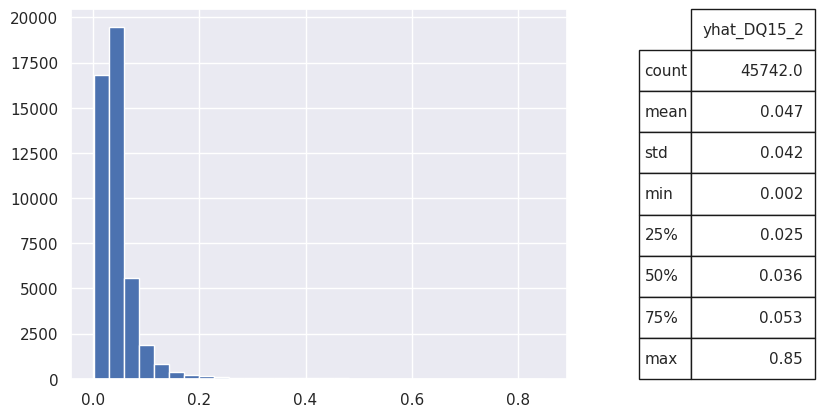

In [9]:
output_dir_sr = 'output'

!rm -rf $output_dir_sr
!mkdir $output_dir_sr

ax = steda.plot_histogram(ss=predictions_df[pred_proba_col_sr])
ax.figure.savefig(fname=f'{output_dir_sr}/predictions.png', bbox_inches='tight')
plt.show(); plt.close();

## Read in actuals

In [10]:
actuals_df = pd.read_csv(filepath_or_buffer='../03_data_collection/daysLate2.csv')

actuals_df.info()
actuals_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233914 entries, 0 to 233913
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   bigAccountId  233914 non-null  int64
 1   DQ15_2        233914 non-null  int64
dtypes: int64(2)
memory usage: 3.6 MB


,bigAccountId,DQ15_2
0,1337511,0
1,1337528,0
2,1337539,0
3,1337542,0
4,1337547,0
...,...,...
233909,7535800,0
233910,7535834,0
233911,7535868,0
233912,7537484,0


## Plot

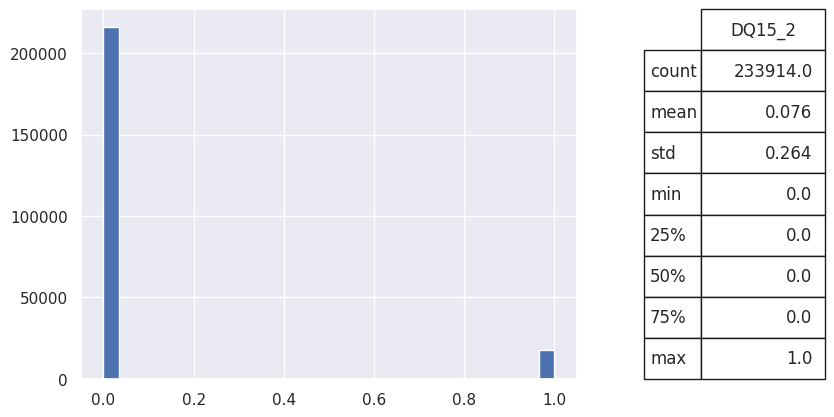

In [11]:
ax = steda.plot_histogram(ss=actuals_df[target_col_sr])
ax.figure.savefig(fname=f'{output_dir_sr}/actuals.png', bbox_inches='tight')
plt.show(); plt.close();

## Merge

In [12]:
merged_df = predictions_df.merge(
    right=actuals_df,
    how='left', left_on=account_col_sr, right_on=account_col_sr2, 
    validate='one_to_one')

merged_df

,uniqueid__app,bigaccountid__app,bigdebtorid__app,applicationdate__app,dtmfunded__app,intopenbktype__app,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd,bigAccountId,DQ15_2
0,587201073673151,5872010,7367315,2021-12-17 14:22:56.113,2022-01-03,0,0.053328,0.383582,0.418932,5872010,0
1,587261273680421,5872612,7368042,2021-12-18 09:38:10.447,2022-01-03,0,0.098879,0.344750,0.371603,5872612,0
2,587778873743361,5877788,7374336,2021-12-23 14:22:38.317,2022-01-03,0,0.017340,0.273659,0.274742,5877788,0
3,587858873753091,5878588,7375309,2021-12-27 07:56:06.063,2022-01-03,7,0.085264,0.146237,0.430430,5878588,0
4,587175073670141,5871750,7367014,2021-12-17 12:21:11.827,2022-01-03,0,0.047832,0.200363,0.392036,5871750,0
...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520,8916109,2023-10-04 10:35:22.710,2023-10-27,7,0.079784,0.147046,0.469872,7153520,0
45738,712473488808771,7124734,8880878,2023-09-22 10:43:32.273,2023-10-27,0,0.081122,0.468691,0.455732,7124734,0
45739,714986089117031,7149860,8911703,2023-10-02 15:50:26.067,2023-10-27,13,0.026729,0.113157,0.301897,7149860,0
45740,705912388008391,7059123,8800840,2023-08-25 11:21:26.143,2023-10-27,0,0.048146,0.346584,0.362954,7059123,0


## Read in tiers

In [13]:
tiers_df = pd.read_csv(filepath_or_buffer='../03_data_collection/tiers.csv', header=None)
tier_col_sr = 'strTier'
tiers_df.columns = [account_col_sr, tier_col_sr]

tiers_df.info()
tiers_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323473 entries, 0 to 323472
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   bigaccountid__app  323473 non-null  int64 
 1   strTier            323473 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.9+ MB


,bigaccountid__app,strTier
0,560701,Tier 5
1,394862,Tier 1
2,876873,C
3,303338,Tier 1
4,305064,Tier 2
...,...,...
323468,3683055,B
323469,2346470,A1
323470,1920812,D
323471,5922632,B


## Merge

In [14]:
merged_df = merged_df.merge(
    right=tiers_df,
    how='left', on=account_col_sr,
    validate='one_to_one')

merged_df

,uniqueid__app,bigaccountid__app,bigdebtorid__app,applicationdate__app,dtmfunded__app,intopenbktype__app,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd,bigAccountId,DQ15_2,strTier
0,587201073673151,5872010,7367315,2021-12-17 14:22:56.113,2022-01-03,0,0.053328,0.383582,0.418932,5872010,0,C
1,587261273680421,5872612,7368042,2021-12-18 09:38:10.447,2022-01-03,0,0.098879,0.344750,0.371603,5872612,0,B
2,587778873743361,5877788,7374336,2021-12-23 14:22:38.317,2022-01-03,0,0.017340,0.273659,0.274742,5877788,0,C
3,587858873753091,5878588,7375309,2021-12-27 07:56:06.063,2022-01-03,7,0.085264,0.146237,0.430430,5878588,0,B
4,587175073670141,5871750,7367014,2021-12-17 12:21:11.827,2022-01-03,0,0.047832,0.200363,0.392036,5871750,0,A
...,...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520,8916109,2023-10-04 10:35:22.710,2023-10-27,7,0.079784,0.147046,0.469872,7153520,0,B
45738,712473488808771,7124734,8880878,2023-09-22 10:43:32.273,2023-10-27,0,0.081122,0.468691,0.455732,7124734,0,D
45739,714986089117031,7149860,8911703,2023-10-02 15:50:26.067,2023-10-27,13,0.026729,0.113157,0.301897,7149860,0,A1
45740,705912388008391,7059123,8800840,2023-08-25 11:21:26.143,2023-10-27,0,0.048146,0.346584,0.362954,7059123,0,D


## Get crosstab

In [15]:
crosstab_df = pd.crosstab(index=merged_df[tier_col_sr], columns=merged_df[target_col_sr])

crosstab_df

DQ15_2,0,1
strTier,,
A,6494,731
A1,5714,399
B,16470,2883
C,6262,1792
D,3664,1320
Gold,11,0
Platinum,2,0


## Drop small tiers with no positive class values

These will throw an error if not

In [16]:
positive_ss = crosstab_df[1]
tiers_lt = positive_ss.index[positive_ss > 0].tolist()

print(tiers_lt)
print(merged_df.shape)

merged_df.query(expr=f'{tier_col_sr}.isin(values={tiers_lt})', inplace=True)

print(merged_df.shape)

['A', 'A1', 'B', 'C', 'D']
(45742, 12)
(45729, 12)


## Get URIs

In [17]:
uris_ss = pd.Series(data=wr.s3.list_objects(path=f's3://{bucket_sr}/*GenXII*'), name='uris')

uris_ss.tolist()

['s3://20231010-gen-xii/11_monitoring/input/GenXIIPerformanceMonitoringTarget.csv']

## Read in previous actuals used in training

In [18]:
assert uris_ss.shape[0] == 1

previous_actuals_df = pd.read_csv(filepath_or_buffer=uris_ss[0], usecols=columns_lt2)

previous_actuals_df.info()
previous_actuals_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196839 entries, 0 to 196838
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   UniqueID      196839 non-null  int64
 1   bigAccountId  196839 non-null  int64
 2   bigDebtorId   196839 non-null  int64
 3   DQ15_2        196839 non-null  int64
dtypes: int64(4)
memory usage: 6.0 MB


,UniqueID,bigAccountId,bigDebtorId,DQ15_2
0,133754717564901,1337547,1756490,0
1,133757917565301,1337579,1756530,0
2,133769917566881,1337699,1756688,0
3,133786117569021,1337861,1756902,0
4,133789717569521,1337897,1756952,0
...,...,...,...,...
196834,481006061269301,4810060,6126931,0
196835,481159061288331,4811590,6128834,0
196836,481194961292901,4811949,6129291,0
196837,481249761299911,4812497,6129992,0


## Get threshold

In [19]:
threshold_ft = previous_actuals_df[target_col_sr].mean()

threshold_ft

0.048547289917140406

## Add columns (prediction, etc.)

In [20]:
pred_col_sr = 'pred'
binarized_bk_col_sr = 'bk'
merged_df = merged_df.assign(**{
    pred_col_sr: lambda x: x[pred_proba_col_sr] > threshold_ft,
    binarized_bk_col_sr: lambda x: x[bk_col_sr] != 0})

merged_df

,uniqueid__app,bigaccountid__app,bigdebtorid__app,applicationdate__app,dtmfunded__app,intopenbktype__app,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd,bigAccountId,DQ15_2,strTier,pred,bk
0,587201073673151,5872010,7367315,2021-12-17 14:22:56.113,2022-01-03,0,0.053328,0.383582,0.418932,5872010,0,C,True,False
1,587261273680421,5872612,7368042,2021-12-18 09:38:10.447,2022-01-03,0,0.098879,0.344750,0.371603,5872612,0,B,True,False
2,587778873743361,5877788,7374336,2021-12-23 14:22:38.317,2022-01-03,0,0.017340,0.273659,0.274742,5877788,0,C,False,False
3,587858873753091,5878588,7375309,2021-12-27 07:56:06.063,2022-01-03,7,0.085264,0.146237,0.430430,5878588,0,B,True,True
4,587175073670141,5871750,7367014,2021-12-17 12:21:11.827,2022-01-03,0,0.047832,0.200363,0.392036,5871750,0,A,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520,8916109,2023-10-04 10:35:22.710,2023-10-27,7,0.079784,0.147046,0.469872,7153520,0,B,True,True
45738,712473488808771,7124734,8880878,2023-09-22 10:43:32.273,2023-10-27,0,0.081122,0.468691,0.455732,7124734,0,D,True,False
45739,714986089117031,7149860,8911703,2023-10-02 15:50:26.067,2023-10-27,13,0.026729,0.113157,0.301897,7149860,0,A1,False,True
45740,705912388008391,7059123,8800840,2023-08-25 11:21:26.143,2023-10-27,0,0.048146,0.346584,0.362954,7059123,0,D,False,False


## Evaluate

Facet: None
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.72      0.79     38604
           1       0.21      0.41      0.28      7125

    accuracy                           0.67     45729
   macro avg       0.54      0.57      0.53     45729
weighted avg       0.77      0.67      0.71     45729



accuracy_score             0.672987
balanced_accuracy_score    0.566149
log_loss                   0.523593
roc_auc_score              0.599980
dtype: float64

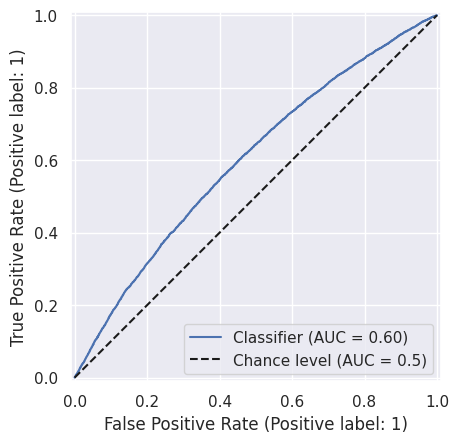

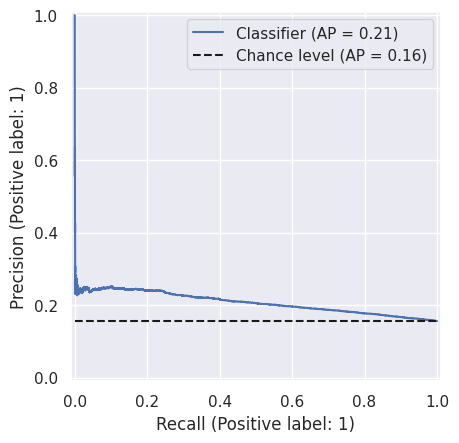

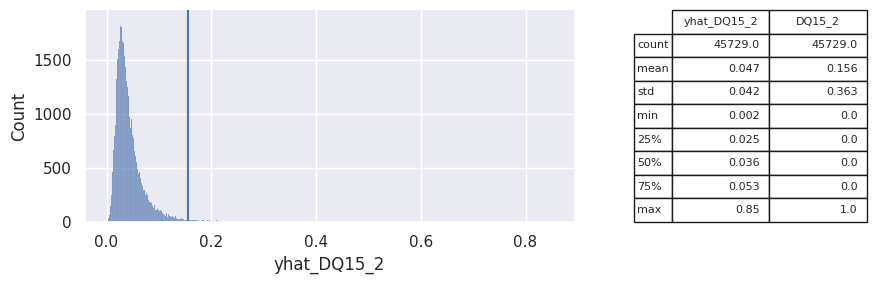

Facet: bk
--------------------------------------------------------------------------------
False
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     28903
           1       0.22      0.34      0.27      5499

    accuracy                           0.71     34402
   macro avg       0.54      0.56      0.54     34402
weighted avg       0.76      0.71      0.73     34402

--------------------------------------------------------------------------------
True
              precision    recall  f1-score   support

           0       0.91      0.55      0.69      9701
           1       0.20      0.66      0.31      1626

    accuracy                           0.57     11327
   macro avg       0.55      0.61      0.50     11327
weighted avg       0.81      0.57      0.63     11327



,False,True
accuracy_score,0.707953,0.566787
balanced_accuracy_score,0.557311,0.607589
log_loss,0.548919,0.446671
roc_auc_score,0.594082,0.646344


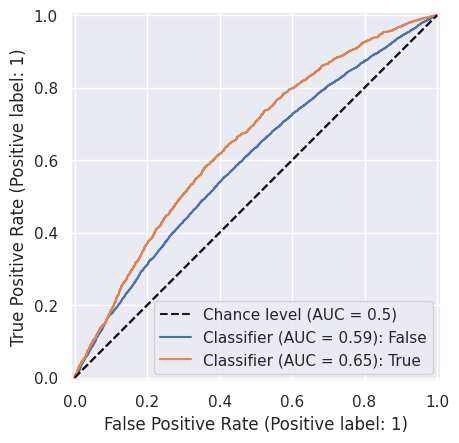

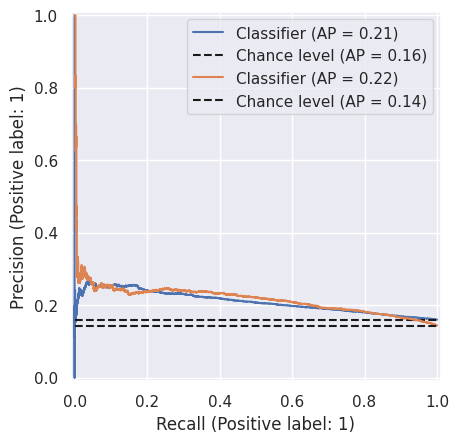

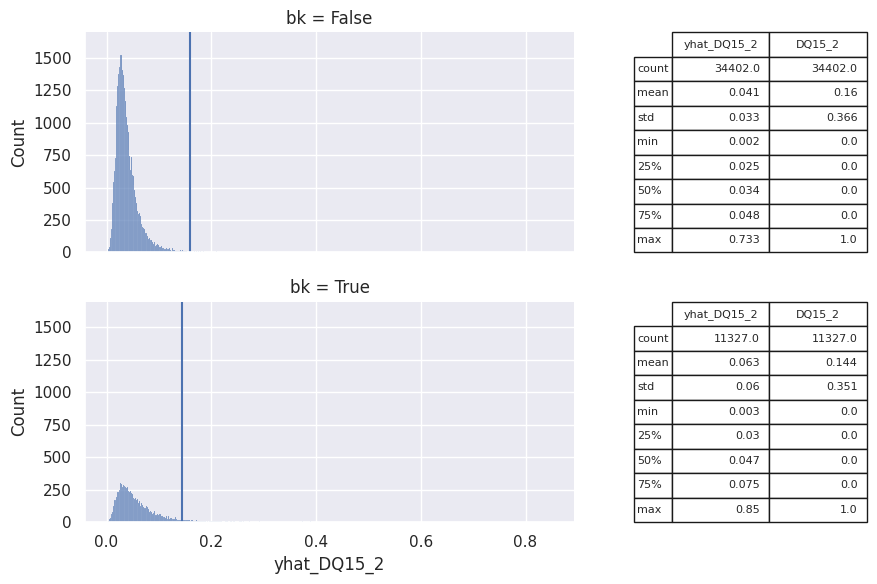

Facet: intopenbktype__app
--------------------------------------------------------------------------------
0
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     28903
           1       0.22      0.34      0.27      5499

    accuracy                           0.71     34402
   macro avg       0.54      0.56      0.54     34402
weighted avg       0.76      0.71      0.73     34402

--------------------------------------------------------------------------------
13
              precision    recall  f1-score   support

           0       0.94      0.65      0.77      2610
           1       0.17      0.63      0.27       297

    accuracy                           0.65      2907
   macro avg       0.55      0.64      0.52      2907
weighted avg       0.86      0.65      0.72      2907

--------------------------------------------------------------------------------
7
              precision    recall  f1-score   support

           0   

,0,13,7
accuracy_score,0.707953,0.647403,0.538955
balanced_accuracy_score,0.557311,0.639527,0.593289
log_loss,0.548919,0.336129,0.484836
roc_auc_score,0.594082,0.685038,0.627922


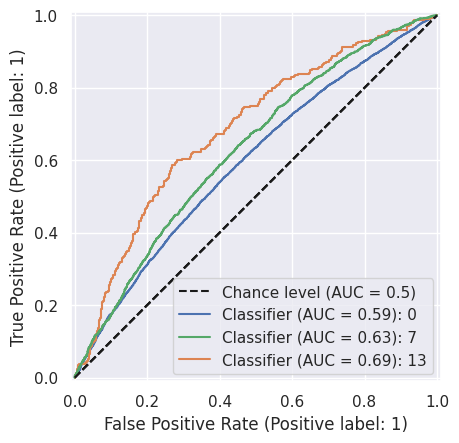

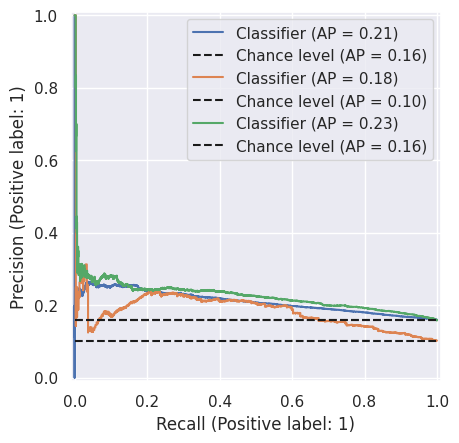

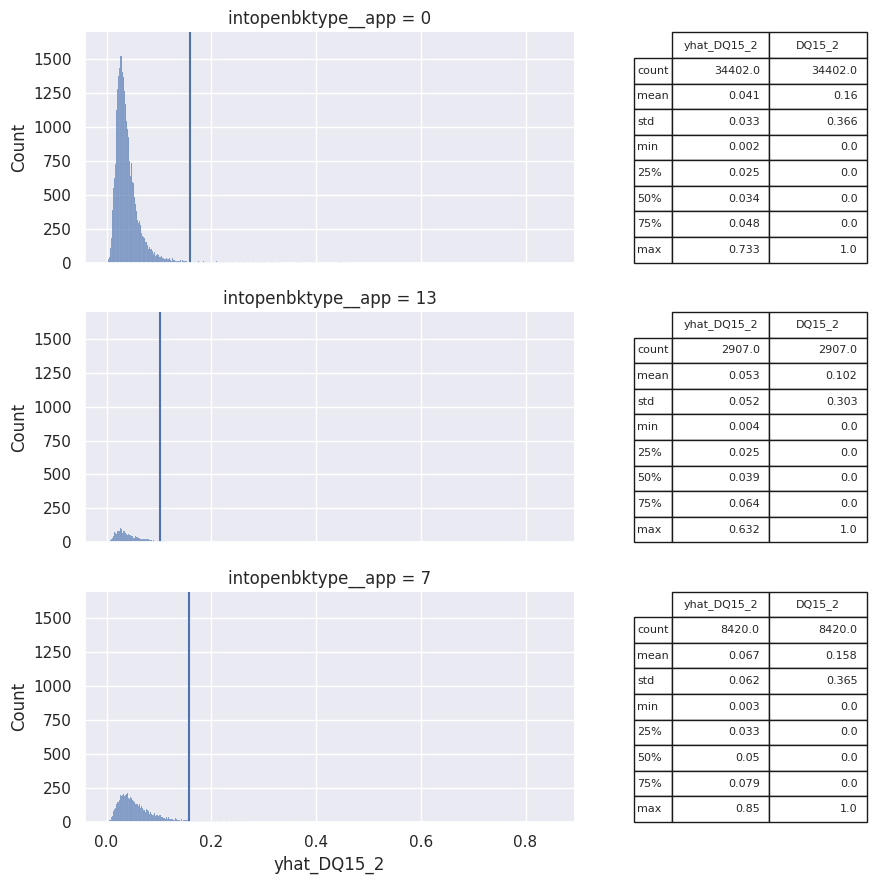

Facet: strTier
--------------------------------------------------------------------------------
A
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      6494
           1       0.15      0.42      0.22       731

    accuracy                           0.71      7225
   macro avg       0.54      0.58      0.52      7225
weighted avg       0.84      0.71      0.76      7225

--------------------------------------------------------------------------------
A1
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      5714
           1       0.11      0.35      0.17       399

    accuracy                           0.78      6113
   macro avg       0.53      0.58      0.52      6113
weighted avg       0.89      0.78      0.83      6113

--------------------------------------------------------------------------------
B
              precision    recall  f1-score   support

           0       0.87   

,A,A1,B,C,D
accuracy_score,0.705882,0.777850,0.696843,0.592625,0.533909
balanced_accuracy_score,0.579019,0.580437,0.550623,0.537458,0.534694
log_loss,0.357450,0.245224,0.514343,0.720863,0.822999
roc_auc_score,0.614018,0.642198,0.569468,0.546443,0.549838


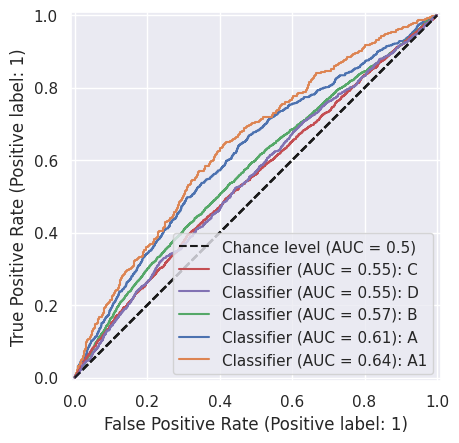

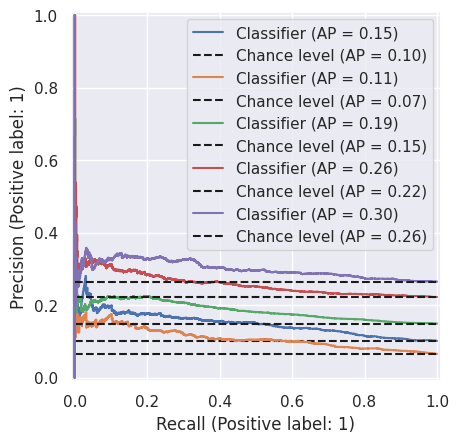

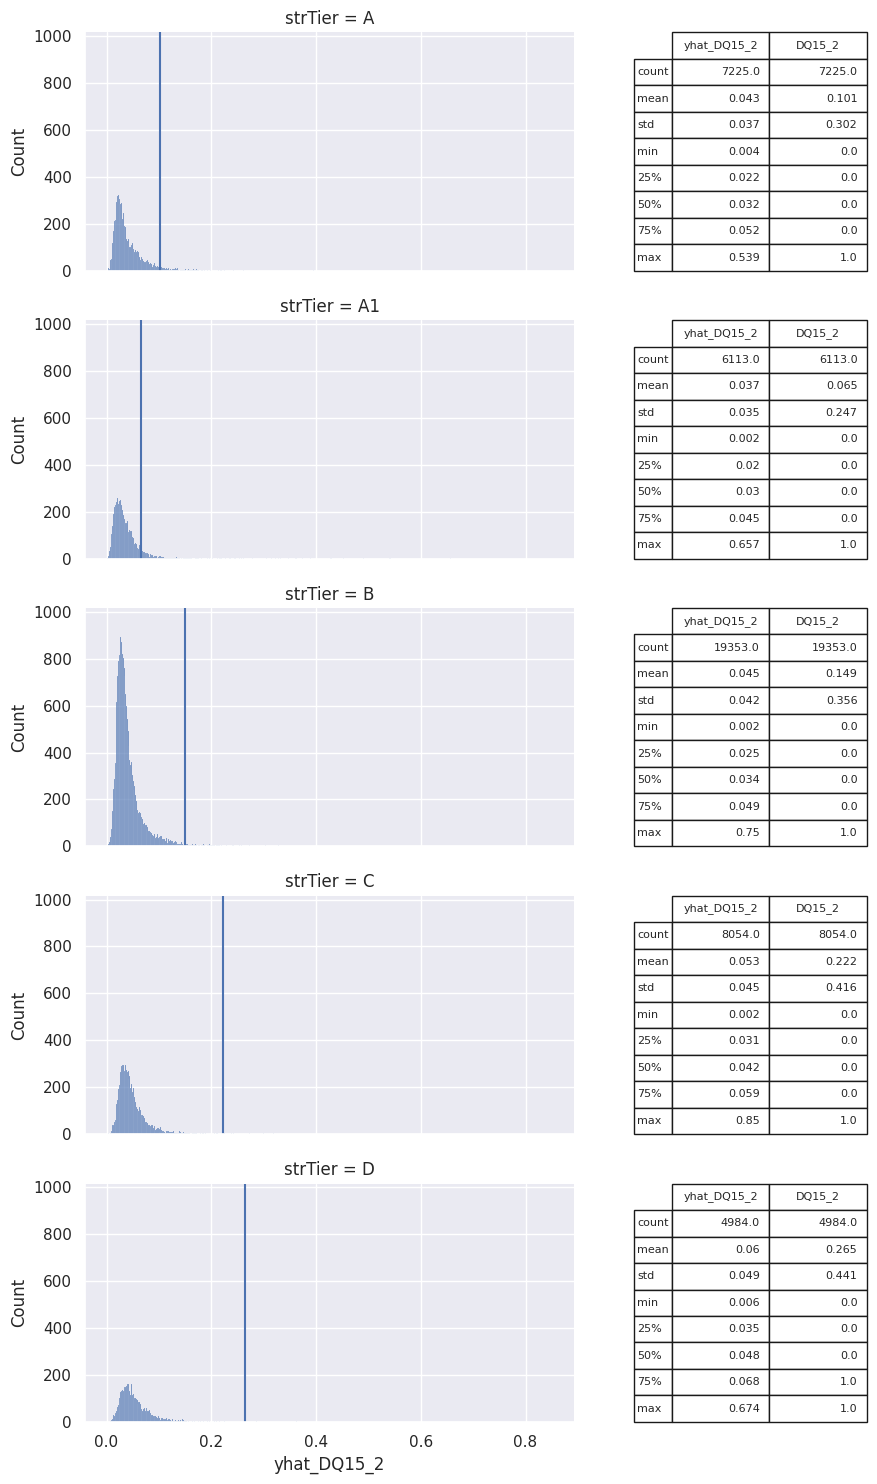

In [21]:
evaluators_dt = {}

for facet_col_sr in [None, binarized_bk_col_sr, bk_col_sr, tier_col_sr]:
    # Log
    print('=' * int(8e1), f'Facet: {facet_col_sr}', sep='\n')
    
    # Fit
    er = Evaluator(
        target_col_sr=target_col_sr,
        pred_col_sr=pred_col_sr,
        pred_proba_col_sr=pred_proba_col_sr, 
        facet_col_sr=facet_col_sr)
    er.fit(merged_df=merged_df)
    
    # Persist evaluator
    facet_col_sr = str(facet_col_sr)
    evaluators_dt[facet_col_sr] = er
    output_subdir_sr = os.path.join(output_dir_sr, facet_col_sr)
    os.mkdir(path=output_subdir_sr)
    pd.to_pickle(obj=er, filepath_or_buffer=os.path.join(output_subdir_sr, 'er.pkl'), protocol=4)
    
    # Persist classification report
    with open(file=os.path.join(output_subdir_sr, 'classification_report_dt.json'), mode='w') as fe:
        json.dump(obj=er.classification_report_dt, fp=fe)
        
    # Persist other metrics
    try:
        display(pd.DataFrame(data=er.other_metrics_dt))
    except:
        display(pd.Series(data=er.other_metrics_dt))
    with open(file=os.path.join(output_subdir_sr, 'other_metrics_dt.json'), mode='w') as fe:
        json.dump(obj=er.other_metrics_dt, fp=fe)
        
    # Persist ROC curve
    display(er.rcd.figure_); plt.show(); plt.close()
    er.rcd.figure_.savefig(fname=os.path.join(output_subdir_sr, 'roc_curve.png'), bbox_inches='tight')
    
    # Persist PR curve
    display(er.prd.figure_); plt.show(); plt.close()
    er.prd.figure_.savefig(fname=os.path.join(output_subdir_sr, 'pr_curve.png'), bbox_inches='tight')
    
    # Persist predictions plot
    display(er.predictions_fig); plt.show(); plt.close()
    er.predictions_fig.savefig(fname=os.path.join(output_subdir_sr, 'predictions.png'), bbox_inches='tight')